# Inference Monitoring Notebook

Post-deployment monitoring workflow for the fraud detection model:

1. **Single Inference Test** — Invoke the endpoint with individual samples (JSON format)
2. **Bulk Inference Test** — Bulk predictions with latency stats
3. **Ground Truth Simulation** — Generate simulated ground truth and apply updates
4. **Monitoring Infrastructure** — Create monitoring_responses table, SQS queue, and Lambda
5. **Monitoring Runs** — Data drift + model drift detection with MLflow logging
6. **Batch Transform** — Offline bulk scoring (optional)
7. **Automated Drift Monitoring** — EventBridge + Lambda + SNS for scheduled monitoring

**Quick Start:**
1. Run Setup cells to initialize
2. Run Sections 1-2 to generate inference predictions (automatically logged to Athena)
3. Run Section 3 to simulate and apply ground truth (for development/testing)
4. Run Section 4 once to set up monitoring infrastructure
5. Run Section 5 to monitor drift and performance

**Important Notes:**
- The endpoint uses a **custom inference handler** that automatically logs all predictions to Athena
- Input format: **JSON** (not CSV) with 30 training features
- Predictions are buffered and flushed to Athena asynchronously (50 records or 5 minutes)
- No manual logging needed - happens automatically in the background

**Environment:** SageMaker AI Notebook or local with AWS credentials.

## Setup

In [1]:
import sys, os, json, time, logging, uuid
from pathlib import Path
from datetime import datetime, timedelta

import boto3
import pandas as pd
import numpy as np

# Find project root and add to path
project_root = Path.cwd()
while not (project_root / '.env').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / '.env')

from src.config.config import (
    ATHENA_DATABASE, DATA_S3_BUCKET, AWS_DEFAULT_REGION,
    ATHENA_OUTPUT_S3,
    ATHENA_TRAINING_TABLE, ATHENA_EVALUATION_TABLE,
    ATHENA_INFERENCE_TABLE,
    ATHENA_GROUND_TRUTH_UPDATES_TABLE,
    CSV_DRIFTED_DATA,
    TRAINING_FEATURES, TARGET_COLUMN,
    SAGEMAKER_EXEC_ROLE, MLFLOW_MODEL_NAME,
    MONITORING_DATA_DRIFT_LOOKBACK_DAYS,
    GROUND_TRUTH_SIM_ACCURACY,
    GROUND_TRUTH_SIM_FEATURE_DRIFT_MAG,
    GROUND_TRUTH_SIM_FEATURE_DRIFT_COUNT,
    GROUND_TRUTH_SIM_FEATURE_DRIFT_IMPACT,
    GROUND_TRUTH_SIM_MODEL_DRIFT_MAG,
)
from src.train_pipeline.athena.athena_client import AthenaClient

# Data source policy:
#   - training_data, evaluation_data, monitoring_responses, inference_responses
#     are read from Athena (single source of truth across runs).
#   - drifted samples (cell 11) are read from the local CSV that cells 6/8
#     just wrote — they are a transient per-run artifact, not durable state.

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

ENDPOINT_NAME = 'fraud-detector-endpoint'
REGION = AWS_DEFAULT_REGION

runtime_client = boto3.client('sagemaker-runtime', region_name=REGION)
sm_client = boto3.client('sagemaker', region_name=REGION)
athena_client = AthenaClient()

print(f'Region: {REGION}')
print(f'Endpoint: {ENDPOINT_NAME}')
print(f'Athena DB: {ATHENA_DATABASE}')
print(f'S3 Bucket: {DATA_S3_BUCKET}')
print(f'MLflow URI: {os.getenv("MLFLOW_TRACKING_URI", "NOT SET")}')
print(f'Data Drift Lookback: {MONITORING_DATA_DRIFT_LOOKBACK_DAYS} days')


2026-06-26 02:27:25,940 - INFO - Initialized AthenaClient for database: fraud_detection


Region: us-west-2
Endpoint: fraud-detector-endpoint
Athena DB: fraud_detection
S3 Bucket: fraud-detection-monitoring-data-<ACCOUNT_ID>
MLflow URI: arn:aws:sagemaker:us-west-2:<ACCOUNT_ID>:mlflow-tracking-server/fraud-detection-monitoring-mlflow
Data Drift Lookback: 7 days


In [2]:
# Configuration Constants (loaded from .env)
# These variables can be overridden in .env file

# Lambda Functions
DRIFT_LAMBDA_NAME = os.getenv('DRIFT_LAMBDA_NAME', 'fraud-detection-drift-monitor')
MONITORING_WRITER_LAMBDA = os.getenv('MONITORING_WRITER_LAMBDA_NAME', 'fraud-monitoring-results-writer')

# SQS Queues
MONITORING_SQS_QUEUE_NAME = os.getenv('MONITORING_SQS_QUEUE_NAME', 'fraud-monitoring-results')

# SNS Topics
SNS_TOPIC_NAME = os.getenv('SNS_TOPIC_NAME', 'fraud-detection-drift-alerts')

# EventBridge Rules
EVENTBRIDGE_RULE_NAME = os.getenv('EVENTBRIDGE_RULE_NAME', 'fraud-detection-drift-check')

# CloudWatch
CLOUDWATCH_DASHBOARD_NAME = os.getenv('CLOUDWATCH_DASHBOARD_NAME', 'FraudDetection-DriftMonitoring')
CLOUDWATCH_NAMESPACE = os.getenv('CLOUDWATCH_NAMESPACE', 'FraudDetection/DriftMonitoring')
CLOUDWATCH_LOG_GROUP_DRIFT = os.getenv('CLOUDWATCH_LOG_GROUP_DRIFT', f'/aws/lambda/{DRIFT_LAMBDA_NAME}')

# Athena Tables
MONITORING_TABLE_NAME = os.getenv('MONITORING_TABLE_NAME', 'monitoring_responses')

print('Configuration loaded:')
print(f'  Drift Lambda: {DRIFT_LAMBDA_NAME}')
print(f'  Monitoring Writer: {MONITORING_WRITER_LAMBDA}')
print(f'  Monitoring Table: {ATHENA_DATABASE}.{MONITORING_TABLE_NAME}')
print(f'  SNS Topic: {SNS_TOPIC_NAME}')
print(f'  EventBridge Rule: {EVENTBRIDGE_RULE_NAME}')

Configuration loaded:
  Drift Lambda: fraud-detection-drift-monitor
  Monitoring Writer: fraud-monitoring-results-writer
  Monitoring Table: fraud_detection.monitoring_responses
  SNS Topic: fraud-detection-drift-alerts
  EventBridge Rule: fraud-detection-drift-check


## 1. Single Inference Test

Invoke the deployed serverless endpoint with individual samples to verify it's working.

## Optional: Generate Drifted Test Data

**This cell is optional** - skip it if you already have drifted test data or don't need to regenerate it.

Generate a drifted dataset for testing drift detection. All drift parameters are configured in `src/config/config.yaml` under `drift_generation.default_drift`.

**To adjust drift amounts:**
1. Edit `src/config/config.yaml` → `drift_generation.default_drift`
2. Run the cell below to regenerate
3. Test with the new drift levels

**Features drifted (default config):**
- `transaction_amount`: +40% increase
- `distance_from_home_km`: 2x increase (100%)
- `velocity_score`: +50% increase
- `num_transactions_24h`: +3 transactions
- `transaction_timestamp`: +50,000 time shift

In [3]:
# Generate drifted dataset (configured via config.yaml)
import subprocess
import sys

print('=' * 80)
print('GENERATING DRIFTED TEST DATA')
print('=' * 80)
print('\nThis will create data/creditcard_drifted.csv with configurable drift amounts.')
print('Drift parameters are read from: src/config/config.yaml → drift_generation.default_drift\n')

result = subprocess.run(
    [sys.executable, 'src/drift_monitoring/generate_drift_dataset.py'],
    cwd=Path.cwd().parent,  # Run from project root
    capture_output=True,
    text=True
)

print(result.stdout)
if result.returncode != 0:
    print('❌ Error generating drifted dataset:')
    print(result.stderr)
else:
    print('\n✅ Drifted dataset generated successfully!')
    print('   File: data/creditcard_drifted.csv')
    print('   To use this data, send it to your endpoint for inference testing.')

GENERATING DRIFTED TEST DATA

This will create data/creditcard_drifted.csv with configurable drift amounts.
Drift parameters are read from: src/config/config.yaml → drift_generation.default_drift



  Local training data not found, using S3 source: s3://fraud-detection-monitoring-data-<ACCOUNT_ID>/fraud-detection/data/creditcard_predictions_final.csv
GENERATING DRIFTED DATASET

Loading original dataset from: s3://fraud-detection-monitoring-data-<ACCOUNT_ID>/fraud-detection/data/creditcard_predictions_final.csv
Original dataset shape: (284807, 35)

Sampling 5000 random rows...
Sampled dataset shape: (5000, 35)

Applying feature drift:
--------------------------------------------------------------------------------
  transaction_amount:
    Original mean: 91.5086
    Drifted mean: 100.6719
    Change: +10.01%
    Description: Increased transaction amounts (inflation/behavior change)
  transaction_timestamp:
    Original mean: 95762.3350
    Drifted mean: 105760.3329
    Change: +10.44%
    Description: Time shift to simulate future period
  distance_from_home_km:
    Original mean: -0.0080
    Drifted mean: 0.5302
    Change: -6768.71%
    Description: Increased distance from home (

### Optional: Generate Variable Drift Patterns

**Also optional** - generates 6 time-varying drift scenarios (run1-run6) for testing drift over time.

This creates more realistic test data simulating different monitoring periods:
- **run1**: Baseline (minimal drift)
- **run2**: Distance spike (travel surge)
- **run3**: Credit limit anomaly (8x spike → PSI ~74)
- **run4**: High velocity period
- **run5**: Recovery
- **run6**: Account age anomaly

**To reduce credit_limit spike from 8x to 1.5x:**
1. Edit `src/config/config.yaml` → `drift_generation.variable_patterns.run3.credit_limit.factor`
2. Change `factor: 8.0` to `factor: 1.5`
3. Run the cell below

In [4]:
# Generate variable drift patterns (6 time-based scenarios)
import subprocess
import sys

print('=' * 80)
print('GENERATING VARIABLE DRIFT PATTERNS (run1-run6)')
print('=' * 80)
print('\nThis will create 6 CSV files simulating different time periods.')
print('Configuration: src/config/config.yaml → drift_generation.variable_patterns\n')

result = subprocess.run(
    [sys.executable, 'src/drift_monitoring/generate_variable_drift_dataset.py'],
    cwd=Path.cwd().parent,  # Run from project root
    capture_output=True,
    text=True
)

print(result.stdout)
if result.returncode != 0:
    print('❌ Error generating variable drift patterns:')
    print(result.stderr)
else:
    print('\n✅ Variable drift patterns generated successfully!')
    print('   Files: data/drifted_data_run1.csv through data/drifted_data_run6.csv')
    print('   Use these for time-series drift testing and QuickSight dashboards.')

GENERATING VARIABLE DRIFT PATTERNS (run1-run6)

This will create 6 CSV files simulating different time periods.
Configuration: src/config/config.yaml → drift_generation.variable_patterns



  Local training data not found, using S3 source: s3://fraud-detection-monitoring-data-<ACCOUNT_ID>/fraud-detection/data/creditcard_predictions_final.csv
VARIABLE DRIFT DATASET GENERATION

Generating 6 monitoring run datasets
Samples per run: 2000
Output directory: /home/sagemaker-user/sample-mlops-bestpractices/sagemaker-automated-drift-and-trend-monitoring/data

Loading training data: s3://fraud-detection-monitoring-data-<ACCOUNT_ID>/fraud-detection/data/creditcard_predictions_final.csv
Original dataset shape: (284807, 35)
Columns: transaction_id, transaction_timestamp, transaction_hour, transaction_day_of_week, customer_age, account_age_days, merchant_category_code, distance_from_home_km, distance_from_last_transaction_km, online_transaction...

GENERATING RUN: run1
Description: Baseline - Minimal drift (normal operations)
Features to drift: 2

Applying drift to 2 features:
--------------------------------------------------------------------------------
    📊 transaction_amount: 99.

### Optional: Send Drifted Data to Endpoint

**This cell actually USES the drifted data** by sending it to your endpoint for inference.

**Important:** This is how drifted data gets into Athena for drift detection!

Without this step, the drifted CSV just sits unused and drift detection compares training vs training data.

**What this does:**
1. Loads `data/creditcard_drifted.csv` (the CSV you just generated)
2. Sends samples to your endpoint
3. Endpoint logs predictions to Athena
4. Drift detection (later cells) will compare these drifted predictions vs training baseline

**Result:** You'll see HIGH drift scores because the data actually has drift!

In [5]:
def invoke_endpoint_json(endpoint_name, feature_dict):
    """Invoke endpoint with JSON format (custom handler with Athena logging)."""
    import json
    import time
    
    payload = json.dumps(feature_dict)
    start = time.time()
    
    response = runtime_client.invoke_endpoint(
        EndpointName=endpoint_name,
        ContentType='application/json',  # Custom handler expects JSON
        Body=payload
    )
    
    latency_ms = (time.time() - start) * 1000
    result = json.loads(response['Body'].read().decode())
    
    # Custom handler returns: {"predictions": [0], "probabilities": {"fraud": [0.1234], "non_fraud": [0.8766]}}
    fraud_prob = result["probabilities"]["fraud"][0]
    prediction = result["predictions"][0]
    
    return {'prediction': prediction, 'fraud_probability': fraud_prob}, latency_ms


In [6]:
# Send drifted data to the endpoint so it lands in Athena inference_responses.
#
# The drifted CSV (data/creditcard_drifted.csv) is a transient artifact
# produced by cells 6 or 8 in this same notebook. Reading it locally is
# fine — we don't need durable storage for it.
#
# FUTURE: upload drifted batches to s3://.../drifted_data/ so the Athena
# `drifted_data` external table can serve them. That would let a retraining
# job pull "production-shifted" samples directly from Athena to refresh
# the training set without needing the local files. Not implemented yet.

if not CSV_DRIFTED_DATA.exists():
    print(f'⚠️  Drifted CSV not found: {CSV_DRIFTED_DATA}')
    print('   Run cell 6 (or cell 8 for variable patterns) first.')
else:
    print(f'Loading drifted test data from: {CSV_DRIFTED_DATA}')
    drifted_df = pd.read_csv(CSV_DRIFTED_DATA)
    print(f'Loaded {len(drifted_df):,} drifted samples')

    feature_cols = [f for f in TRAINING_FEATURES if f in drifted_df.columns]

    # Sample subset for testing (default 100)
    NUM_DRIFTED_TESTS = 100
    drifted_samples = drifted_df.sample(n=min(NUM_DRIFTED_TESTS, len(drifted_df)), random_state=456)

    print(f'\nSending {len(drifted_samples)} drifted samples to endpoint...')
    print(f'Endpoint: {ENDPOINT_NAME}')

    success_count = 0
    error_count = 0
    for idx, row in drifted_samples.iterrows():
        try:
            feature_dict = row[feature_cols].to_dict()
            result, latency = invoke_endpoint_json(ENDPOINT_NAME, feature_dict)
            success_count += 1
            if success_count % 20 == 0:
                print(f'  Progress: {success_count}/{len(drifted_samples)}...')
        except Exception as e:
            error_count += 1
            if error_count == 1:
                print(f'  ⚠️  Error on sample {idx}: {e}')

    print(f'\n✅ Sent {success_count}/{len(drifted_samples)} drifted samples to endpoint')
    if error_count > 0:
        print(f'   ⚠️  {error_count} errors occurred')
    print(f'\n📊 These drifted predictions are now in Athena inference_responses!')
    print(f'   When you run drift detection (later cells), it will compare:')
    print(f'   - Baseline: frozen evaluation_data Iceberg table')
    print(f'   - Current: Athena inference_responses (drifted distributions)')


Loading drifted test data from: /home/sagemaker-user/sample-mlops-bestpractices/sagemaker-automated-drift-and-trend-monitoring/data/creditcard_drifted.csv
Loaded 5,000 drifted samples

Sending 100 drifted samples to endpoint...
Endpoint: fraud-detector-endpoint


  Progress: 20/100...


  Progress: 40/100...


  Progress: 60/100...


  Progress: 80/100...


  Progress: 100/100...

✅ Sent 100/100 drifted samples to endpoint

📊 These drifted predictions are now in Athena inference_responses!
   When you run drift detection (later cells), it will compare:
   - Baseline: frozen evaluation_data Iceberg table
   - Current: Athena inference_responses (drifted distributions)


In [7]:
# Load sample inference test data from the Athena training_data table.
# No local CSV dependency — the table is populated either by CFN seed or
# by notebook 1's data setup step.

sample_query = f"""
SELECT {', '.join(TRAINING_FEATURES)}, is_fraud
FROM {ATHENA_DATABASE}.{ATHENA_TRAINING_TABLE}
LIMIT 5000
"""
print(f'Loading sample data from {ATHENA_DATABASE}.{ATHENA_TRAINING_TABLE}...')
test_df = athena_client.execute_query(sample_query)

# customer_gender is stored as STRING in Athena (DDL: STRING; everything else DOUBLE).
# The training pipeline already encodes it to '0'/'1' before writing — but Athena
# round-trips it as a Python string, so we cast it back to int explicitly.
# Cast the remaining 29 features straight to numeric.
numeric_features = [f for f in TRAINING_FEATURES if f != 'customer_gender']
for col in numeric_features:
    if col in test_df.columns:
        test_df[col] = pd.to_numeric(test_df[col], errors='coerce')
if 'customer_gender' in test_df.columns:
    test_df['customer_gender'] = pd.to_numeric(test_df['customer_gender'], errors='coerce')

# Drop rows where ALL feature columns are NaN (i.e. truly empty rows).
# A single bad column shouldn't disqualify a sample.
test_df = test_df.dropna(subset=TRAINING_FEATURES, how='all')
print(f'Loaded {len(test_df):,} rows')

# Verify all features exist
missing = [f for f in TRAINING_FEATURES if f not in test_df.columns]
if missing:
    print(f'⚠ Missing features: {missing}')
else:
    print(f'✓ All {len(TRAINING_FEATURES)} training features found')

feature_cols = TRAINING_FEATURES
print(f'Feature columns for inference: {len(feature_cols)}')
test_df.head(3)


2026-06-26 02:27:57,438 - INFO - Executing query: 
SELECT transaction_hour, transaction_day_of_week, transaction_amount, transaction_type_code, custom...


Loading sample data from fraud_detection.training_data...


2026-06-26 02:28:01,116 - INFO - Initializing a Ray instance


2026-06-26 02:28:04,066	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 408924160 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.64gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-06-26 02:28:06,273	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-06-26 02:28:07,791 - INFO - Query returned 5000 rows


Loaded 5,000 rows
✓ All 30 training features found
Feature columns for inference: 30


,transaction_hour,transaction_day_of_week,transaction_amount,transaction_type_code,customer_age,customer_gender,customer_tenure_months,account_age_days,distance_from_home_km,distance_from_last_transaction_km,...,num_transactions_24h,num_transactions_7days,avg_transaction_amount_30days,max_transaction_amount_30days,velocity_score,recurring_transaction,previous_fraud_incidents,credit_limit,available_credit_ratio,is_fraud
0,1.954621,-0.075507,5.38,-0.682885,-1.917348,<NA>,-0.478417,0.220071,0.662429,-0.115192,...,-0.582278,1.090647,-0.448692,1.278265,-0.306495,-0.287555,-0.044741,0.279835,-0.020158,False
1,-0.903036,0.072315,15.00,0.003175,0.625922,<NA>,0.899901,-3.233390,-0.066333,-0.292694,...,-0.328003,-0.719953,-0.183223,0.248803,-0.218311,-1.916454,0.033603,-0.089479,0.134046,False
2,-1.090239,1.944019,0.00,-0.286638,-3.086137,<NA>,-1.047032,-0.556876,-1.684399,0.482978,...,2.076218,-1.548346,-0.166743,-0.098631,0.537311,-0.403928,0.264933,0.409617,0.353284,False


In [8]:
# Test with a few samples
NUM_SINGLE_TESTS = 5
samples = test_df.sample(n=NUM_SINGLE_TESTS, random_state=42)

print(f'Testing {NUM_SINGLE_TESTS} individual invocations ({len(feature_cols)} features)...\n')
for i, (idx, row) in enumerate(samples.iterrows(), 1):
    feature_dict = row[feature_cols].to_dict()
    actual_label = row.get('is_fraud', 'N/A')

    result, latency = invoke_endpoint_json(ENDPOINT_NAME, feature_dict)

    print(f'Sample {i}: prediction={result["prediction"]}, '
          f'fraud_prob={result["fraud_probability"]:.4f}, '
          f'actual={actual_label}, latency={latency:.0f}ms')

print('\n✓ Single inference tests complete')

Testing 5 individual invocations (30 features)...



Sample 1: prediction=0, fraud_prob=0.0428, actual=False, latency=8061ms
Sample 2: prediction=1, fraud_prob=0.5685, actual=False, latency=153ms


Sample 3: prediction=0, fraud_prob=0.0373, actual=False, latency=51ms
Sample 4: prediction=0, fraud_prob=0.0370, actual=False, latency=52ms
Sample 5: prediction=0, fraud_prob=0.0489, actual=False, latency=51ms

✓ Single inference tests complete


In [9]:
# Quick test - verify endpoint uses custom handler with JSON format
import json

# Test with a single sample using JSON format (custom handler)
test_payload = {
    "transaction_hour": 14,
    "transaction_day_of_week": 2,
    "transaction_amount": 149.62,
    "transaction_type_code": 1,
    "customer_age": 42,
    "customer_gender": 0,
    "customer_tenure_months": 36,
    "account_age_days": 1095,
    "distance_from_home_km": 5.2,
    "distance_from_last_transaction_km": 2.3,
    "time_since_last_transaction_min": 120,
    "online_transaction": 1,
    "international_transaction": 0,
    "high_risk_country": 0,
    "merchant_category_code": 5411,
    "merchant_reputation_score": 0.85,
    "chip_transaction": 1,
    "pin_used": 1,
    "card_present": 1,
    "cvv_match": 1,
    "address_verification_match": 1,
    "num_transactions_24h": 3,
    "num_transactions_7days": 12,
    "avg_transaction_amount_30days": 125.50,
    "max_transaction_amount_30days": 450.00,
    "velocity_score": 0.3,
    "recurring_transaction": 0,
    "previous_fraud_incidents": 0,
    "credit_limit": 5000.0,
    "available_credit_ratio": 0.75
}

response = runtime_client.invoke_endpoint(
    EndpointName=ENDPOINT_NAME,
    ContentType='application/json',
    Body=json.dumps(test_payload)
)
result = json.loads(response['Body'].read().decode())
print(f"Response: {result}")
print(f"  Prediction: {result['predictions'][0]}")
print(f"  Fraud probability: {result['probabilities']['fraud'][0]:.4f}")


Response: {'predictions': [0], 'probabilities': {'non_fraud': [0.8451991081237793], 'fraud': [0.15480086207389832]}}
  Prediction: 0
  Fraud probability: 0.1548


### SageMaker Studio Endpoint Playground

**Access:** SageMaker Studio > Deployments > Endpoints > Fraud Detector Endpoint > Playground

Copy the JSON payload below and paste it into the endpoint playground.

**Configuration:**
- Content-Type: `application/json`
- Format: JSON with 30 training features

**Important:** The custom inference handler expects JSON format, not CSV.

SageMaker Studio Endpoint Playground - Sample Payloads
Endpoint: fraud-detector-endpoint
Content-Type: application/json
Features: 30

--- Sample 1 (actual is_fraud=False) ---
{
  "transaction_hour": -0.578003762653866,
  "transaction_day_of_week": 1.47181931225406,
  "transaction_amount": 7.59,
  "transaction_type_code": -0.0558771389701806,
  "customer_age": 1.13672198806629,
  "customer_gender": null,
  "customer_tenure_months": 0.179900844282104,
  "account_age_days": 2.31177958314245,
  "distance_from_home_km": -0.385246678006087,
  "distance_from_last_transaction_km": 1.29530708186444,
  "time_since_last_transaction_min": -0.352753898240839,
  "online_transaction": -0.0572904058029224,
  "international_transaction": -1.27051089149606,
  "high_risk_country": -1.11388929846006,
  "merchant_category_code": 1.17530488177953,
  "merchant_reputation_score": 0.684246443718132,
  "chip_transaction": -1.87425522972552,
  "pin_used": 0.554623895520758,
  "card_present": -0.0921955031874429,

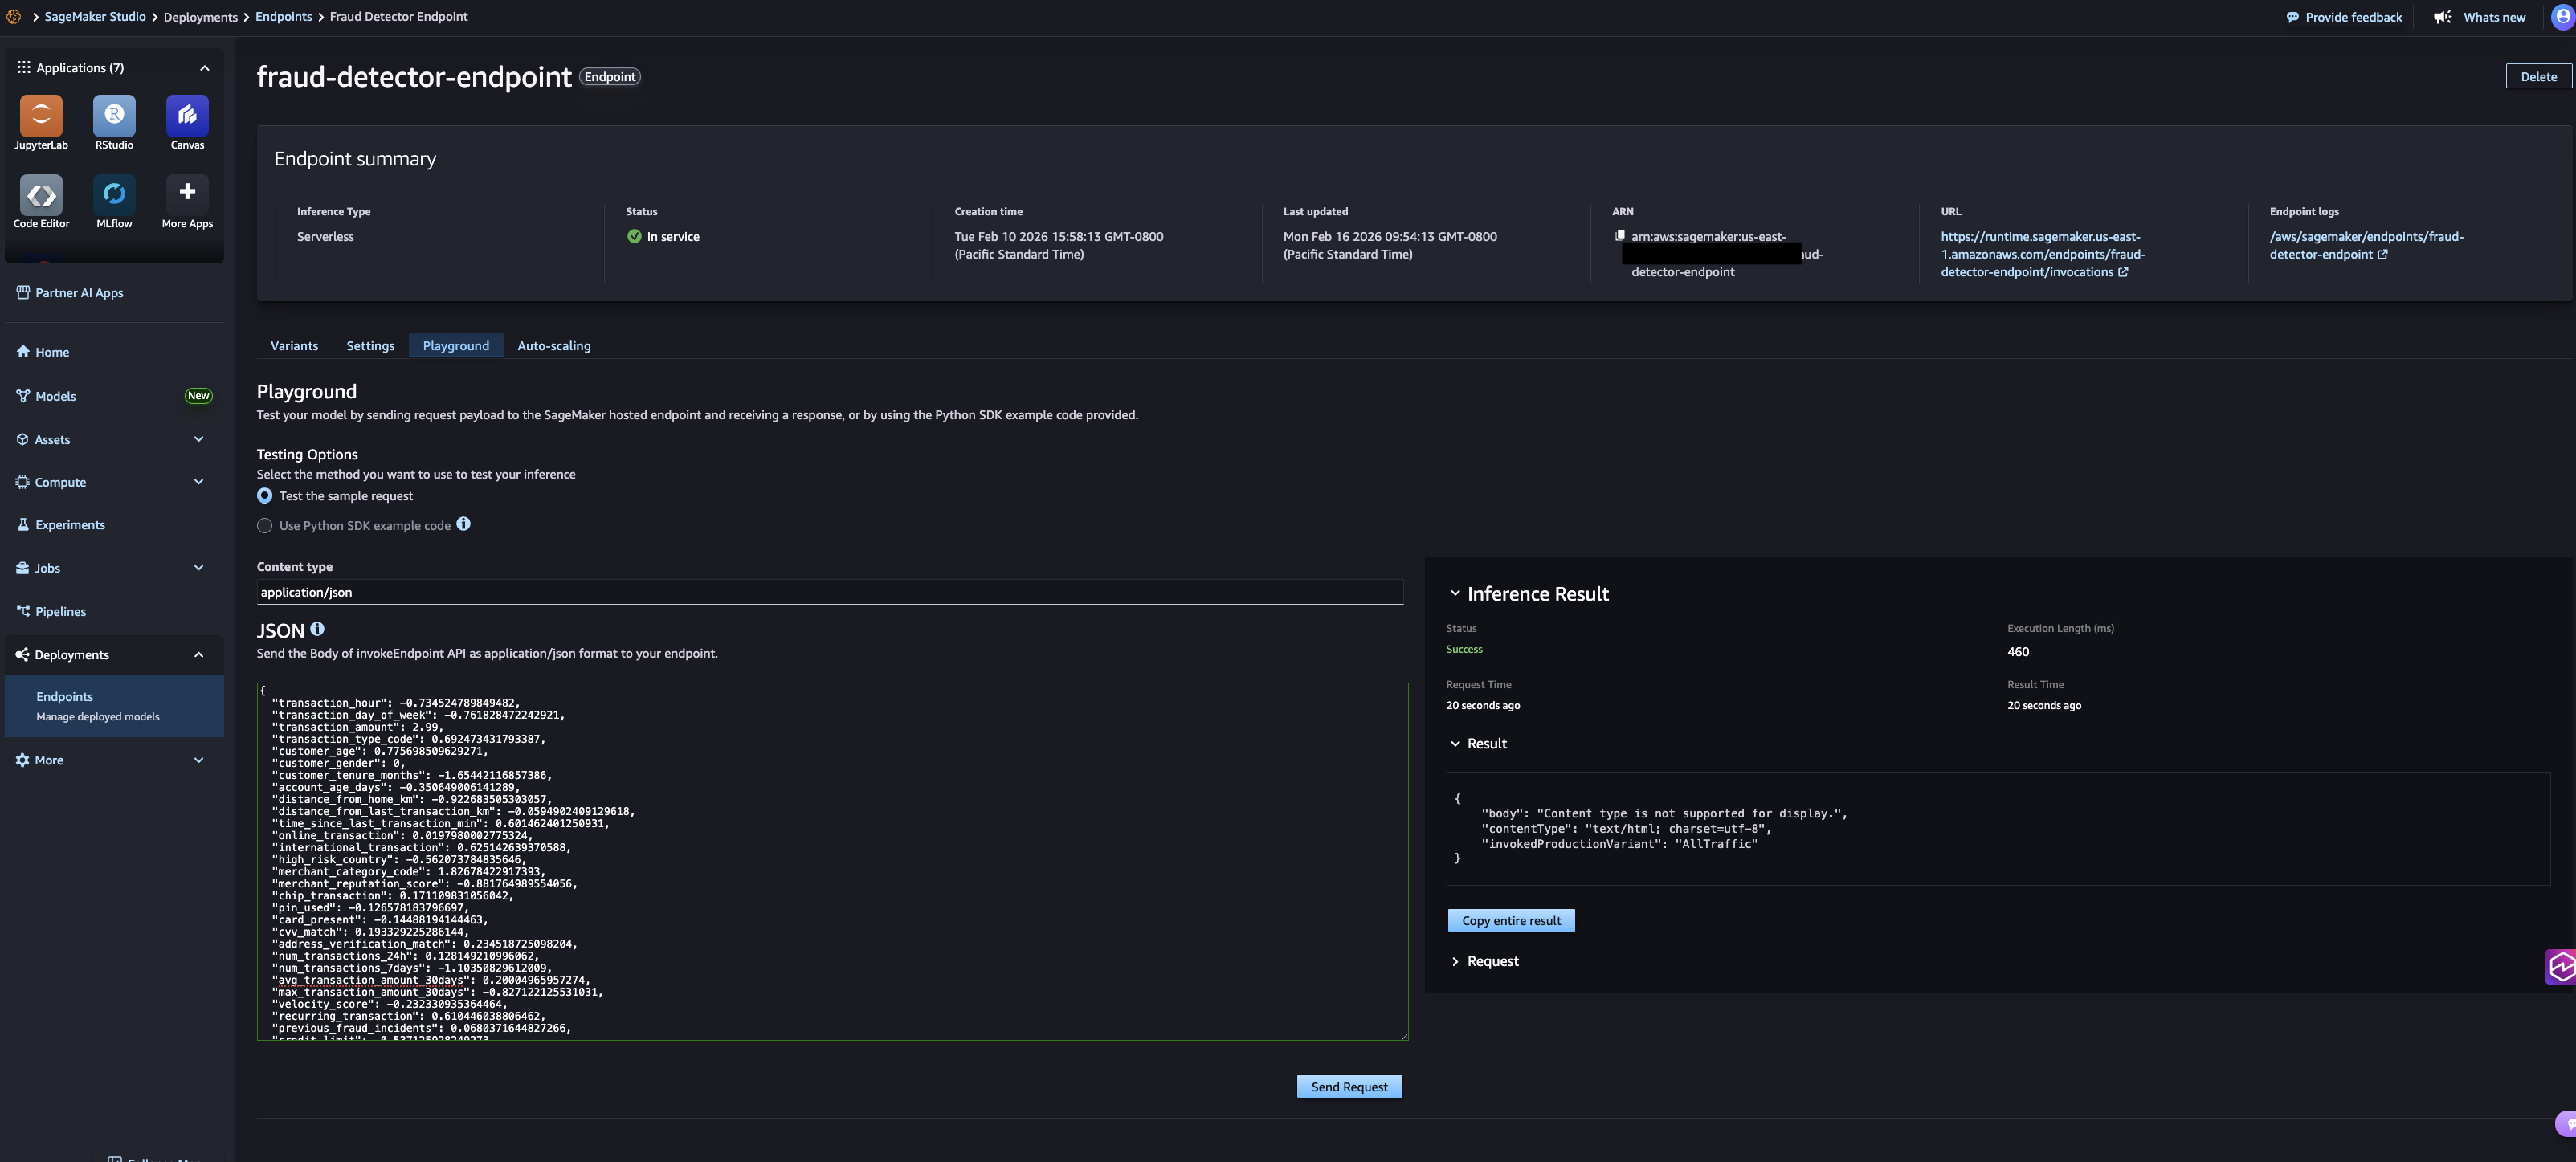

In [10]:
# Generate sample JSON payloads for SageMaker Studio endpoint playground
# Content-Type: application/json

# Verify feature count before generating samples
assert len(feature_cols) == 30, f"Expected 30 features, got {len(feature_cols)}"

num_playground_samples = 3
playground_samples = test_df.sample(n=num_playground_samples, random_state=99)

print('=' * 80)
print('SageMaker Studio Endpoint Playground - Sample Payloads')
print(f'Endpoint: {ENDPOINT_NAME}')
print(f'Content-Type: application/json')
print(f'Features: {len(feature_cols)}')
print('=' * 80)

for i, (idx, row) in enumerate(playground_samples.iterrows(), 1):
    feature_dict = row[feature_cols].to_dict()
    # Convert to JSON string
    json_payload = json.dumps(feature_dict, indent=2)
    actual = row.get('is_fraud', '?')
    print(f'\n--- Sample {i} (actual is_fraud={actual}) ---')
    print(json_payload)

print('\n' + '=' * 80)
print('Copy any JSON object above and paste into the endpoint playground.')
print('Expected response format:')
print('  {"predictions": [0], "probabilities": {"fraud": [0.1234], "non_fraud": [0.8766]}}')

# Display screenshot showing how to use the SageMaker Studio Endpoint Playground
from IPython.display import Image, display
screenshot_path = project_root / 'docs' / 'screenshots' / 'DirectTestingInSGPlayground-custom-handler.png'
if screenshot_path.exists():
    print('\n\nHow to test in SageMaker Studio Endpoint Playground:')
    display(Image(filename=str(screenshot_path), width=800))
else:
    print(f'\n⚠ Screenshot not found at: {screenshot_path}')

## 2. Bulk Inference Test

Run multiple predictions to test throughput and collect latency statistics.

In [11]:
# Bulk JSON invocation test with latency stats
NUM_BULK_TESTS = 101
bulk_samples = test_df.sample(n=NUM_BULK_TESTS, random_state=123)

predictions = []
latencies = []
errors = []

print(f'Running {NUM_BULK_TESTS} JSON invocations...')
for idx, row in bulk_samples.iterrows():
    try:
        feature_dict = row[feature_cols].to_dict()
        result, latency = invoke_endpoint_json(ENDPOINT_NAME, feature_dict)
        predictions.append(result)
        latencies.append(latency)
    except Exception as e:
        errors.append(str(e))

latencies_arr = np.array(latencies)
print(f'\nResults:')
print(f'  Successful: {len(predictions)}/{NUM_BULK_TESTS}')
print(f'  Errors: {len(errors)}')
print(f'  Avg latency: {latencies_arr.mean():.0f}ms')
print(f'  P50 latency: {np.percentile(latencies_arr, 50):.0f}ms')
print(f'  P95 latency: {np.percentile(latencies_arr, 95):.0f}ms')
print(f'  P99 latency: {np.percentile(latencies_arr, 99):.0f}ms')

# Prediction distribution
fraud_preds = sum(1 for p in predictions if p['prediction'] == 1)
print(f'  Fraud predictions: {fraud_preds}/{len(predictions)} ({fraud_preds/len(predictions)*100:.1f}%)')

Running 101 JSON invocations...



Results:
  Successful: 101/101
  Errors: 0
  Avg latency: 48ms
  P50 latency: 46ms
  P95 latency: 59ms
  P99 latency: 70ms
  Fraud predictions: 0/101 (0.0%)


In [12]:
# ✓ Automatic Athena Logging Enabled
# The custom inference handler automatically logs all predictions to Athena.
# No manual logging needed!

# How it works:
# - Every prediction is captured by the custom handler and sent to SQS
# - SQS-triggered Lambda batches records and writes to the Athena Iceberg table
# - Batch flush: 10 records (SQS BatchSize)
# - Time flush: 30 seconds (SQS MaximumBatchingWindowInSeconds)

# Verify automatic logging:
print("Checking automatic Athena logging...")

query = f"""
SELECT COUNT(*) as total,
       CAST(MIN(request_timestamp) AS TIMESTAMP(3)) as earliest,
       CAST(MAX(request_timestamp) AS TIMESTAMP(3)) as latest
FROM {ATHENA_DATABASE}.inference_responses
"""
#WHERE endpoint_name = '{ENDPOINT_NAME}'
result = athena_client.execute_query(query)

if not result.empty:
    print(f"✓ Found {result['total'].iloc[0]:,} predictions in Athena")
    print(f"  Time range: {result['earliest'].iloc[0]} to {result['latest'].iloc[0]}")
    print(f"\nAutomatic logging is working! No manual step needed.")
else:
    print("⚠ No predictions found yet.")
    print("  Run cells 6-9 to generate predictions.")
    print("  Wait for buffer to flush (10 records or 30 seconds)")


2026-06-26 02:28:21,291 - INFO - Executing query: 
SELECT COUNT(*) as total,
       CAST(MIN(request_timestamp) AS TIMESTAMP(3)) as earliest,
       C...


Checking automatic Athena logging...


2026-06-26 02:28:22,768 - INFO - Query returned 1 rows


✓ Found 0 predictions in Athena
  Time range: NaT to NaT

Automatic logging is working! No manual step needed.


## 3. Ground Truth Simulation & Update

In production, ground truth arrives asynchronously as fraud investigations complete. For development and testing, we can simulate ground truth to test the monitoring pipeline.

**Workflow:**
1. **Simulate Ground Truth** (Section 3.1) — Generate realistic fraud/non-fraud labels
2. **Apply Updates** (Section 3.1) — Merge simulated ground truth into inference_responses
3. **Verify Coverage** (Section 3.2) — Confirm ground truth is applied

**Production Note:** In a real production environment, ground truth would come from your fraud investigation system that writes confirmed fraud/non-fraud labels to the `ground_truth_updates` Athena table. The simulation is only for development and testing.

### 3.1 Simulate Ground Truth (Development/Testing)

For development and testing, you can simulate ground truth by randomly assigning fraud/non-fraud labels to your inference predictions. This is useful when:
- Testing the monitoring pipeline before production
- Training your team on drift detection
- Demonstrating the monitoring functionality

**Two options:**

1. **Command-line script** (recommended for batch simulation):
   ```bash
   python scripts/simulate_ground_truth_from_athena.py --accuracy 0.85
   python scripts/update_ground_truth.py --mode batch
   ```

2. **Programmatic approach** (in this notebook - see cell below)

In [13]:
# Ground truth simulation parameters come from src.config.config
# (sourced from src/config/config.yaml → ground_truth_simulation):
#   GROUND_TRUTH_SIM_ACCURACY
#   GROUND_TRUTH_SIM_FEATURE_DRIFT_MAG
#   GROUND_TRUTH_SIM_FEATURE_DRIFT_COUNT
#   GROUND_TRUTH_SIM_FEATURE_DRIFT_IMPACT
#   GROUND_TRUTH_SIM_MODEL_DRIFT_MAG
#
# To adjust these values, edit src/config/config.yaml → ground_truth_simulation
print(f'Simulation accuracy: {GROUND_TRUTH_SIM_ACCURACY:.2f}')
print(f'Feature drift: mag={GROUND_TRUTH_SIM_FEATURE_DRIFT_MAG:.2f}, '
      f'count={GROUND_TRUTH_SIM_FEATURE_DRIFT_COUNT}, '
      f'impact={GROUND_TRUTH_SIM_FEATURE_DRIFT_IMPACT:.2f}')
print(f'Model drift: {GROUND_TRUTH_SIM_MODEL_DRIFT_MAG:.2f}')


Simulation accuracy: 0.85
Feature drift: mag=0.00, count=0, impact=0.00
Model drift: 0.00


In [14]:
# Option 1: Run the simulation programmatically (default, used below)
# The simulator module lives at src/drift_monitoring/simulate_ground_truth_from_athena.py

# NOTE: SQS→Lambda inference logging is async. If you just ran bulk tests,
# wait ~60 seconds for all records to land in Athena before simulating.
import time
print('Waiting 30s for async SQS→Lambda writes to complete...')
time.sleep(30)

# Option 2: Simulate ground truth programmatically (in notebook)
from src.drift_monitoring.simulate_ground_truth_from_athena import GroundTruthSimulator

# Create simulator with configured drift parameters
simulator = GroundTruthSimulator(
    athena_client=athena_client,
    endpoint_name=ENDPOINT_NAME,
    accuracy=GROUND_TRUTH_SIM_ACCURACY,
    fraud_confirmation_days=(1, 7),
    non_fraud_confirmation_days=(1, 30),
    feature_drift_magnitude=GROUND_TRUTH_SIM_FEATURE_DRIFT_MAG,
    feature_drift_count=GROUND_TRUTH_SIM_FEATURE_DRIFT_COUNT,
    feature_drift_impact=GROUND_TRUTH_SIM_FEATURE_DRIFT_IMPACT,
    model_drift_magnitude=GROUND_TRUTH_SIM_MODEL_DRIFT_MAG,
    seed=42
)

# Run simulation
print("Simulating ground truth for predictions without ground truth...")
stats = simulator.simulate_and_write(limit=None)  # Set limit=100 to only process 100 predictions

print("\n" + "=" * 80)
print("Simulation Summary")
print("=" * 80)

if stats['total_predictions'] > 0:
    print(f"Predictions processed: {stats['total_predictions']:,}")
    print(f"Ground truth updates created: {stats['updates_created']:,}")
    print(f"Actual fraud: {stats['actual_fraud']:,} ({stats['actual_fraud']/stats['total_predictions']*100:.1f}%)")
    print(f"False positives: {stats['false_positives']:,}")
    print(f"False negatives: {stats['false_negatives']:,}")
    print(f"Model accuracy: {stats.get('accuracy', GROUND_TRUTH_SIM_ACCURACY)*100:.1f}%")
    print("=" * 80)
    print("\n✅ Ground truth simulation complete!")
    print("   Next: Run the cell below to apply updates to inference_responses table")
else:
    print("⚠️  No predictions found to simulate ground truth")
    print("   Total predictions: 0")
    print("   Possible reasons:")
    print("   - No inference tests have been run yet (run Cells 6-9)")
    print("   - All predictions already have ground truth")
    print("   - Wrong endpoint name filter")
    print("\n   Action: Run Cells 6-9 to generate inference predictions first")
    print("=" * 80)


Waiting 30s for async SQS→Lambda writes to complete...


2026-06-26 02:28:52,801 - INFO - Initialized GroundTruthSimulator:


2026-06-26 02:28:52,801 - INFO -   Base accuracy: 0.85


2026-06-26 02:28:52,802 - INFO -   Effective accuracy: 0.85


2026-06-26 02:28:52,803 - INFO - ================================================================================


...

Simulating ground truth for predictions without ground truth...


2026-06-26 02:28:54,243 - INFO - Query returned 0 rows


2026-06-26 02:28:54,244 - WARNING - No predictions found without ground truth


2026-06-26 02:28:54,245 - WARNING - No predictions to process



Simulation Summary
⚠️  No predictions found to simulate ground truth
   Total predictions: 0
   Possible reasons:
   - No inference tests have been run yet (run Cells 6-9)
   - All predictions already have ground truth
   - Wrong endpoint name filter

   Action: Run Cells 6-9 to generate inference predictions first


In [15]:
# Apply simulated ground truth updates to inference_responses table
print("Applying ground truth updates to inference_responses table...")

# Initialize updater (already imported above)
if 'updater' not in dir():
    from src.drift_monitoring.update_ground_truth import GroundTruthUpdater
    updater = GroundTruthUpdater(athena_client=athena_client, dry_run=False)

# Get statistics before update
print("\nGetting update statistics...")
update_stats = updater.get_update_statistics()

if update_stats['total_updates'] > 0:
    print(f"\nPending updates: {update_stats['total_updates']:,}")
    print(f"  Fraud cases: {update_stats['fraud_cases']:,}")
    print(f"  False positives: {update_stats['false_positives']:,}")
    print(f"  False negatives: {update_stats['false_negatives']:,}")
    print(f"  Avg days to confirmation: {update_stats['avg_days_to_confirmation']:.1f}")
    
    # Execute the update
    print("\nMerging ground truth updates into inference_responses...")
    result = updater.update_ground_truth_batch()
    
    print(f"\n✅ Ground truth update complete!")
    print(f"   Records updated: {result['updated']:,}")
    print(f"\n   Next: Run the cell below to check coverage")
else:
    print("\n⚠️  No pending updates found")
    print("   Make sure you ran the simulation cell above first")

2026-06-26 02:28:54,262 - INFO - Calculating update statistics...


2026-06-26 02:28:54,262 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_updates,
            COALESCE(SUM(CAST(gtu.actual_frau...


Applying ground truth updates to inference_responses table...

Getting update statistics...


2026-06-26 02:28:55,714 - INFO - Query returned 1 rows



⚠️  No pending updates found
   Make sure you ran the simulation cell above first


### 3.2 Verify Ground Truth Coverage

After simulating and applying ground truth updates, verify the coverage to ensure predictions now have ground truth labels.

In [16]:
# Check current ground truth coverage before update
from src.drift_monitoring.update_ground_truth import GroundTruthUpdater

updater = GroundTruthUpdater(athena_client=athena_client, dry_run=False)

coverage_before = updater.get_coverage_statistics()
print('Current ground truth coverage:')
print(f"  Total predictions: {coverage_before['total_predictions']:,}")
print(f"  With ground truth: {coverage_before['with_ground_truth']:,} ({coverage_before['coverage_pct']:.2f}%)")
print(f"  Without ground truth: {coverage_before['without_ground_truth']:,}")

2026-06-26 02:28:55,722 - INFO - Calculating ground truth coverage...


2026-06-26 02:28:55,723 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_predictions,
            COALESCE(SUM(CASE WHEN ground...


2026-06-26 02:28:57,195 - INFO - Query returned 1 rows


Current ground truth coverage:
  Total predictions: 0
  With ground truth: 0 (0.00%)
  Without ground truth: 0


## 4. Monitoring Pipeline Setup

The `monitoring_responses` Iceberg table is created by **CloudFormation** at stack deployment
(`cloudformation/sagemaker-mlflow-setup.yaml` — search for `monitoring_responses`). This section
wires up the runtime pipeline that writes into it:

1. **Lake Formation grants** for the current IAM principal and the Lambda execution role
2. **SQS queue** for monitoring results (used by the drift Lambda → writer Lambda hop)
3. **Monitoring writer Lambda** that consumes the queue and INSERTs into the Athena table

The end-to-end flow once everything is deployed:
`lambda_drift_monitor` → SQS → `lambda_monitoring_writer` → Athena `monitoring_responses`.

### 4.2 Grant Lake Formation Permissions

In [26]:
import boto3, os
from src.config.config import ATHENA_DATABASE, LAMBDA_EXEC_ROLE

lf = boto3.client('lakeformation', region_name=REGION)
sts = boto3.client('sts', region_name=REGION)
identity = sts.get_caller_identity()
caller_arn = identity['Arn']
account_id = identity['Account']

# Lake Formation doesn't accept assumed-role session ARNs (temporary credentials).
# Convert arn:aws:sts::<acct>:assumed-role/<role-name>/<session>
# to     arn:aws:iam::<acct>:role/<role-name>
# For SSO roles, the path is role/aws-reserved/sso.amazonaws.com/<role-name>
if ':assumed-role/' in caller_arn:
    parts = caller_arn.split('/')
    role_name = parts[1]  # e.g. AWSReservedSSO_AdministratorAccess_69906e41ccdeafff
    if role_name.startswith('AWSReservedSSO_'):
        caller_arn = f'arn:aws:iam::{account_id}:role/aws-reserved/sso.amazonaws.com/{role_name}'
    else:
        caller_arn = f'arn:aws:iam::{account_id}:role/{role_name}'
    print(f'Resolved IAM role: {caller_arn}\n')

ALL_TABLES = [
    'training_data',
    'evaluation_data',
    'ground_truth',
    'inference_responses',
    'drifted_data',
    'ground_truth_updates',
    'monitoring_responses',
]

# --- 1. Grant caller (your IAM role/user) access to ALL tables ---
print(f'Granting permissions to caller: {caller_arn}')
print(f'Database: {ATHENA_DATABASE}\n')

for table in ALL_TABLES:
    for perm in ['SELECT', 'DESCRIBE', 'INSERT', 'ALTER']:
        try:
            lf.grant_permissions(
                Principal={'DataLakePrincipalIdentifier': caller_arn},
                Resource={'Table': {'DatabaseName': ATHENA_DATABASE, 'Name': table}},
                Permissions=[perm],
            )
            print(f'\u2713 {perm} on {table}')
        except Exception as e:
            if 'AlreadyExistsException' in str(type(e).__name__) or 'already' in str(e).lower():
                print(f'\u2713 {perm} on {table} (already granted)')
            else:
                print(f'\u2717 {perm} on {table}: {e}')

# --- 2. Grant Lambda role access to monitoring_responses ---
lambda_role_arn = LAMBDA_EXEC_ROLE
if lambda_role_arn:
    print(f'\nGranting Lambda role permissions: {lambda_role_arn}')
    for perm in ['SELECT', 'DESCRIBE', 'INSERT', 'ALTER']:
        try:
            lf.grant_permissions(
                Principal={'DataLakePrincipalIdentifier': lambda_role_arn},
                Resource={'Table': {'DatabaseName': ATHENA_DATABASE, 'Name': MONITORING_TABLE_NAME}},
                Permissions=[perm],
            )
            print(f'\u2713 {perm} on monitoring_responses (Lambda role)')
        except Exception as e:
            if 'AlreadyExistsException' in str(type(e).__name__) or 'already' in str(e).lower():
                print(f'\u2713 {perm} on monitoring_responses (Lambda role, already granted)')
            else:
                print(f'\u2717 {perm} on monitoring_responses (Lambda role): {e}')
else:
    print('\n\u26a0 LAMBDA_EXEC_ROLE not set in .env, skipping Lambda grants')

print('\n\u2713 Lake Formation grants complete')

Resolved IAM role: arn:aws:iam::<ACCOUNT_ID>:role/fraud-detection-monitoring-SageMakerExecutionRole

Granting permissions to caller: arn:aws:iam::<ACCOUNT_ID>:role/fraud-detection-monitoring-SageMakerExecutionRole
Database: fraud_detection

✓ SELECT on training_data


✓ DESCRIBE on training_data
✓ INSERT on training_data


✓ ALTER on training_data
✓ SELECT on evaluation_data


✓ DESCRIBE on evaluation_data
✓ INSERT on evaluation_data


✓ ALTER on evaluation_data
✓ SELECT on ground_truth


...

✓ SELECT on ground_truth_updates
✓ DESCRIBE on ground_truth_updates


✓ INSERT on ground_truth_updates
✓ ALTER on ground_truth_updates


✓ SELECT on monitoring_responses
✓ DESCRIBE on monitoring_responses


✓ INSERT on monitoring_responses


✓ ALTER on monitoring_responses

⚠ LAMBDA_EXEC_ROLE not set in .env, skipping Lambda grants

✓ Lake Formation grants complete


### 4.3 Create SQS Queue & Deploy Monitoring Writer Lambda

Creates the SQS queue for monitoring results and deploys the consumer Lambda that writes to Athena.

In [27]:
# Configuration: Lambda Deployment Control
# Set REDEPLOY_LAMBDAS = True to force redeployment even if no code changes
# Set to False to skip deployment if Lambdas already exist (default)
REDEPLOY_LAMBDAS = True

print(f"Lambda Redeployment: {'ENABLED' if REDEPLOY_LAMBDAS else 'DISABLED (skip if exists)'}")

Lambda Redeployment: ENABLED


In [19]:
# Ensure the drift monitor Lambda role exists with required permissions
import boto3, json, time
from src.config.config import LAMBDA_EXEC_ROLE

iam = boto3.client('iam', region_name=REGION)
ROLE_NAME = LAMBDA_EXEC_ROLE.split('/')[-1] if LAMBDA_EXEC_ROLE else 'fraud-detection-drift-monitor-role'

trust_policy = {
    'Version': '2012-10-17',
    'Statement': [{
        'Effect': 'Allow',
        'Principal': {'Service': 'lambda.amazonaws.com'},
        'Action': 'sts:AssumeRole',
    }],
}

# Create role if it doesn't exist
try:
    iam.get_role(RoleName=ROLE_NAME)
    print(f'\u2713 Role {ROLE_NAME} already exists')
except iam.exceptions.NoSuchEntityException:
    iam.create_role(
        RoleName=ROLE_NAME,
        AssumeRolePolicyDocument=json.dumps(trust_policy),
        Description='Lambda role for fraud detection drift monitoring',
    )
    print(f'\u2713 Created role {ROLE_NAME}')
    time.sleep(5)  # Wait for IAM propagation

# Attach managed policies
managed_policies = [
    'arn:aws:iam::aws:policy/service-role/AWSLambdaBasicExecutionRole',
    'arn:aws:iam::aws:policy/AmazonAthenaFullAccess',
]
for policy_arn in managed_policies:
    try:
        iam.attach_role_policy(RoleName=ROLE_NAME, PolicyArn=policy_arn)
        print(f'\u2713 Attached {policy_arn.split("/")[-1]}')
    except Exception as e:
        print(f'  (already attached or error: {e})')

# Add inline policy for SQS + S3 access
inline_policy = {
    'Version': '2012-10-17',
    'Statement': [
        {
            'Effect': 'Allow',
            'Action': [
                'sqs:ReceiveMessage',
                'sqs:DeleteMessage',
                'sqs:GetQueueAttributes',
            ],
            'Resource': '*',
        },
        {
            'Effect': 'Allow',
            'Action': [
                's3:GetObject',
                's3:PutObject',
                's3:ListBucket',
                's3:GetBucketLocation',
            ],
            'Resource': '*',
        },
    ],
}
iam.put_role_policy(
    RoleName=ROLE_NAME,
    PolicyName='SQS-S3-Access',
    PolicyDocument=json.dumps(inline_policy),
)
print(f'\u2713 Attached inline SQS + S3 policy')

print(f'\n\u2713 Role ready: {ROLE_NAME}')
print(f'  Waiting 10s for IAM propagation...')
time.sleep(10)

✓ Role fraud-detection-drift-monitor-role already exists
✓ Attached AWSLambdaBasicExecutionRole


✓ Attached AmazonAthenaFullAccess
✓ Attached inline SQS + S3 policy

✓ Role ready: fraud-detection-drift-monitor-role
  Waiting 10s for IAM propagation...


In [20]:
# Deploy monitoring results writer Lambda
import boto3
import subprocess

lambda_client = boto3.client('lambda', region_name=REGION)
WRITER_NAME = MONITORING_WRITER_LAMBDA

should_deploy = REDEPLOY_LAMBDAS
if not REDEPLOY_LAMBDAS:
    try:
        lambda_client.get_function(FunctionName=WRITER_NAME)
        print(f"✓ Lambda '{WRITER_NAME}' exists. Skipping deployment.")
        print("  (Set REDEPLOY_LAMBDAS = True to force redeployment)")
    except lambda_client.exceptions.ResourceNotFoundException:
        print(f"Lambda '{WRITER_NAME}' not found. Proceeding with deployment...")
        should_deploy = True
else:
    print("REDEPLOY_LAMBDAS enabled. Forcing redeployment...")

if should_deploy:
    print("=" * 80)
    result = subprocess.run(
        ['python3', '-m', 'src.drift_monitoring.deploy_monitoring_writer', REGION],
        cwd=project_root,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print("ERROR:", result.stderr)
    else:
        print("\n✓ Monitoring writer deployed!")

# Get queue URL for drift monitor
sqs = boto3.client('sqs', region_name=REGION)
try:
    queue_url = sqs.get_queue_url(QueueName=MONITORING_SQS_QUEUE_NAME)['QueueUrl']
    print(f"\nSQS Queue URL: {queue_url}")
    print("(This will be used by the drift monitor Lambda)")
except Exception as e:
    print(f"Note: {e}")


REDEPLOY_LAMBDAS enabled. Forcing redeployment...


╔════════════════════════════════════════════════════════════════════╗
║  Deploying Monitoring Results Writer Lambda                       ║
╚════════════════════════════════════════════════════════════════════╝

  Region: us-west-2
  Account: <ACCOUNT_ID>
  Lambda: fraud-monitoring-results-writer
  Queue: fraud-monitoring-results

[1/5] Creating SQS queue...
  ✓ Queue created: https://sqs.us-west-2.amazonaws.com/<ACCOUNT_ID>/fraud-monitoring-results

[2/5] Creating IAM role...
  ✓ Role exists
  ✓ Policies attached
  Waiting 10s for role propagation...

[3/5] Creating Lambda package...
  ✓ Package created: 1.5 KB

[4/5] Deploying Lambda function...
  ✓ Lambda created

[5/5] Configuring SQS trigger...
  ✓ SQS trigger configured

╔════════════════════════════════════════════════════════════════════╗
║  ✅ MONITORING WRITER DEPLOYED                                     ║
╚════════════════════════════════════════════════════════════════════╝

  Lambda: arn:aws:lambda:us-west-2:<ACCOUNT_ID>:f

### 4.4 Update Drift Monitor Lambda (add SQS env var)

**Note**: This cell updates the drift monitor Lambda **if it already exists**. On first deployment, skip this cell - the Lambda will be created with the correct environment variable in Section 7.2.

This cell is useful for:
- Updating the SQS queue URL if it changes after initial deployment
- Manually adding the environment variable to an existing Lambda

If the Lambda doesn't exist yet, this cell will gracefully fail with a message.

In [21]:
import boto3, time, os

lam = boto3.client('lambda', region_name=REGION)
DRIFT_LAMBDA = os.getenv('DRIFT_LAMBDA_NAME', DRIFT_LAMBDA_NAME)

try:
    config = lam.get_function_configuration(FunctionName=DRIFT_LAMBDA)
    env_vars = config.get('Environment', {}).get('Variables', {})
    env_vars['MONITORING_SQS_QUEUE_URL'] = queue_url

    # Wait for any pending updates
    time.sleep(2)
    lam.update_function_configuration(
        FunctionName=DRIFT_LAMBDA,
        Environment={'Variables': env_vars},
    )
    print(f'\u2713 Added MONITORING_SQS_QUEUE_URL to {DRIFT_LAMBDA}')
    print(f'  Queue URL: {queue_url}')
except Exception as e:
    print(f'Note: Could not update {DRIFT_LAMBDA}: {e}')
    print(f'  Lambda will be created with correct env var in Section 7.2')

Note: Could not update fraud-detection-drift-monitor: An error occurred (ResourceNotFoundException) when calling the GetFunctionConfiguration operation: Function not found: arn:aws:lambda:us-west-2:<ACCOUNT_ID>:function:fraud-detection-drift-monitor
  Lambda will be created with correct env var in Section 7.2


## 5. Monitoring Runs

With ground truth available, we can now compute:
- **Data drift** — PSI and KS tests comparing training vs inference feature distributions
- **Model drift** — Performance metric degradation vs training baseline
- **Performance trends** — Metrics over time windows

Results are logged to MLflow for tracking.

In [22]:
from src.drift_monitoring.monitor_model_performance import ModelPerformanceMonitor

monitor = ModelPerformanceMonitor(
    athena_client=athena_client,
    alert_threshold=0.85,  # ROC-AUC threshold for alerts
    min_samples=50,        # Minimum samples for reliable metrics
)

# Check ground truth coverage
coverage = monitor.get_ground_truth_coverage(endpoint_name=ENDPOINT_NAME, days=30)
print(f"Ground truth coverage (last 30 days):")
print(f"  Total predictions: {coverage['total_predictions']:,}")
print(f"  With ground truth: {coverage['with_ground_truth']:,} ({coverage['coverage_pct']:.2f}%)")

2026-06-26 02:29:25,112 - INFO - Calculating ground truth coverage...


2026-06-26 02:29:25,113 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_predictions,
            COALESCE(SUM(CASE WHEN ground...


2026-06-26 02:29:26,562 - INFO - Query returned 1 rows


Ground truth coverage (last 30 days):
  Total predictions: 0
  With ground truth: 0 (0.00%)


In [23]:
# Generate performance report
report = monitor.generate_performance_report(
    endpoint_name=ENDPOINT_NAME,
    days=7,
    window='D',  # Daily time windows
)

monitor.print_report_summary(report)

2026-06-26 02:29:26,570 - INFO - ================================================================================


2026-06-26 02:29:26,571 - INFO - Model Performance Report


2026-06-26 02:29:26,571 - INFO - ================================================================================


2026-06-26 02:29:26,571 - INFO - Calculating ground truth coverage...


2026-06-26 02:29:26,573 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_predictions,
            COALESCE(SUM(CASE WHEN ground...


...

2026-06-26 02:29:27,989 - INFO -   Total predictions: 0


2026-06-26 02:29:27,990 - INFO -   With ground truth: 0 (0.00%)


2026-06-26 02:29:27,990 - INFO -   Avg days to confirmation: 0.00


2026-06-26 02:29:27,991 - WARNING - 
Insufficient ground truth data (0 samples). Need at least 50 samples for reliable metrics.



Model Performance Summary

Error: insufficient_ground_truth


In [24]:
# Display overall metrics
if report.get('overall_metrics') and 'error' not in report['overall_metrics']:
    metrics = report['overall_metrics']
    print('Overall Model Performance:')
    print(f"  ROC-AUC:    {metrics.get('roc_auc', 'N/A')}")
    print(f"  PR-AUC:     {metrics.get('pr_auc', 'N/A')}")
    print(f"  Precision:  {metrics['precision']:.4f}")
    print(f"  Recall:     {metrics['recall']:.4f}")
    print(f"  F1-Score:   {metrics['f1_score']:.4f}")
    print(f"  Accuracy:   {metrics['accuracy']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {metrics['true_positives']:,}  FP: {metrics['false_positives']:,}")
    print(f"  FN: {metrics['false_negatives']:,}  TN: {metrics['true_negatives']:,}")
else:
    print('Insufficient ground truth data for metrics. Run ground truth update first.')

Insufficient ground truth data for metrics. Run ground truth update first.


### 5.1 Data Drift Detection

In [25]:
from src.drift_monitoring.evidently_reports import run_data_drift_report, run_classification_report
from IPython.display import HTML, display


ModuleNotFoundError: No module named 'evidently'

In [ ]:
from src.drift_monitoring.evidently_reports import run_data_drift_report
from src.config.config import ATHENA_EVALUATION_TABLE

# Load baseline data from the FROZEN evaluation_data Iceberg table.
# This matches what the scheduled drift Lambda uses, so notebook results
# stay consistent with automated runs. The training notebook publishes
# baseline.json with an evaluation_snapshot_id we can pin to (per-version
# reproducibility); we fall back to the live table if no snapshot is
# registered yet.
baseline_snapshot_id = None  # Optionally set to pin a specific Iceberg snapshot
if baseline_snapshot_id:
    baseline_from = f'{ATHENA_DATABASE}.{ATHENA_EVALUATION_TABLE} FOR VERSION AS OF {baseline_snapshot_id}'
    snapshot_log = f'snapshot {baseline_snapshot_id}'
else:
    baseline_from = f'{ATHENA_DATABASE}.{ATHENA_EVALUATION_TABLE}'
    snapshot_log = 'live evaluation_data table (no snapshot pinned)'

baseline_query = f"""
SELECT {', '.join(TRAINING_FEATURES)}
FROM {baseline_from}
WHERE is_fraud IS NOT NULL
LIMIT 5000
"""
print(f'Loading baseline from {snapshot_log}...')
baseline_df = athena_client.execute_query(baseline_query)
for col in baseline_df.columns:
    baseline_df[col] = pd.to_numeric(baseline_df[col], errors='coerce')

numeric_features = [c for c in TRAINING_FEATURES if c in baseline_df.columns]
baseline_numeric = baseline_df[numeric_features].select_dtypes(include=[np.number])

print(f'Baseline: {len(baseline_df):,} samples, {len(baseline_numeric.columns)} numeric features')

# Load inference data from Athena (time-based filter using lookback_days from config)
lookback_start = (datetime.now() - timedelta(days=MONITORING_DATA_DRIFT_LOOKBACK_DAYS)).strftime('%Y-%m-%d %H:%M:%S')
print(f'\nQuerying inference data from last {MONITORING_DATA_DRIFT_LOOKBACK_DAYS} days (since {lookback_start})...')

inference_query = f"""
SELECT
    inference_id,
    request_timestamp,
    endpoint_name,
    prediction,
    probability_fraud,
    input_features,
    transaction_amount
FROM {ATHENA_DATABASE}.{ATHENA_INFERENCE_TABLE}
WHERE endpoint_name = '{ENDPOINT_NAME}'
  AND request_timestamp >= TIMESTAMP '{lookback_start}'
ORDER BY request_timestamp DESC
LIMIT 10000
"""
inference_raw = athena_client.execute_query(inference_query)
print(f'Inference: {len(inference_raw):,} raw samples loaded from Athena')

if not inference_raw.empty:
    import json
    print('\n🔧 Parsing input_features JSON to extract all 30 features...')

    # Parse JSON and extract all features
    feature_rows = []
    for idx, row in inference_raw.iterrows():
        try:
            features_dict = json.loads(row['input_features'])
            feature_values = {feat: features_dict.get(feat, np.nan) for feat in TRAINING_FEATURES}
            feature_rows.append(feature_values)
        except Exception as e:
            print(f'  ⚠ Failed to parse row {idx}: {e}')
            continue

    inference_numeric = pd.DataFrame(feature_rows)
    print(f'✓ Successfully extracted {len(inference_numeric)} samples with {len(inference_numeric.columns)} features')

    # Find common numeric features
    common_features = [c for c in baseline_numeric.columns if c in inference_numeric.columns]
    baseline_for_drift = baseline_numeric[common_features]
    inference_for_drift = inference_numeric[common_features]

    print(f'\n📊 Running Evidently data drift report on {len(common_features)} features...')

    # Run Evidently data drift report
    drift_results = run_data_drift_report(
        baseline_df=baseline_for_drift,
        current_df=inference_for_drift,
    )

    print(f'\n' + '=' * 80)
    print('EVIDENTLY DATA DRIFT ANALYSIS SUMMARY')
    print('=' * 80)
    print(f'  Drift detected: {drift_results["drift_detected"]}')
    print(f'  Drifted columns: {drift_results["drifted_columns_count"]}')
    print(f'  Drifted share: {drift_results["drifted_columns_share"]:.1%}')
    print('=' * 80)
    print('\n✓ Drift detection complete. See interactive report below.')
else:
    print('⚠ No inference data found in Athena for the specified time range. Run inference tests first (Cells 6-9).')


In [ ]:
# Display Evidently data drift report inline
if not inference_raw.empty and 'drift_results' in dir() and drift_results.get('snapshot'):
    print('📊 Evidently Data Drift Report (interactive)')
    print('=' * 80)
    display(drift_results['snapshot'])
    print('\n✓ Evidently data drift report displayed')
else:
    print('No drift results available to visualize.')


> **📸 Report Screenshot:** GitHub cannot render interactive HTML reports. Below is a screenshot from an actual Evidently Data Drift Report logged to MLflow:
>
> ![Data Drift Report](../docs/screenshots/evidently/data-drift-report-screenshot.png)
>
> The full interactive report is available as an MLflow artifact under `evidently_reports/`.

### 📊 KS-Specific Visualizations (Enhanced Drift Detection)

The Kolmogorov-Smirnov (KS) test provides enhanced sensitivity to distribution changes, especially in tails.

**KS Advantages for Fraud Detection:**
- **Tail sensitivity**: Detects rare fraud pattern changes
- **Distribution-free**: No assumptions about underlying distributions
- **Comprehensive**: Captures both location and shape changes
- **Interpretable**: Direct measure of maximum CDF difference

In [ ]:
# KS statistics are included in the Evidently DataDriftPreset report above.
# The interactive report includes per-feature distribution comparisons and statistical tests.
if not inference_raw.empty and 'drift_results' in dir() and drift_results.get('per_column'):
    print('📋 Per-Column Drift Summary (from Evidently report)')
    print('=' * 80)
    for col, info in sorted(drift_results['per_column'].items(), key=lambda x: x[1]['drift_score']):
        status = '⚠ DRIFT' if info['drifted'] else '✓ OK'
        print(f'  {col:35s} p-value={info["drift_score"]:.4f}  [{status}]')
    print('=' * 80)
    print('\n✓ See the interactive Evidently report above for detailed CDF comparisons and heatmaps.')
else:
    print('No drift results available for KS visualization.')


### 5.2 Model Drift Detection

In [ ]:
from src.drift_monitoring.evidently_reports import run_classification_report

# Load predictions with ground truth
gt_df = monitor.load_predictions_with_ground_truth(endpoint_name=ENDPOINT_NAME, days=30)

if len(gt_df) >= 50:
    y_true = gt_df['ground_truth'].values
    y_proba = gt_df['probability_fraud'].values
    y_pred = (y_proba >= 0.5).astype(int)

    # Build current DataFrame with target + prediction columns
    current_model_df = pd.DataFrame({
        'target': y_true.astype(int),
        'prediction': y_pred,
    })

    # Build baseline from the FROZEN evaluation_data table. The training
    # pipeline writes scored predictions back to evaluation_data, so we
    # have target + prediction available without recomputing. This matches
    # what the scheduled drift Lambda uses, so notebook and Lambda results
    # are comparable.
    baseline_query = f"""
    SELECT is_fraud AS target, fraud_prediction AS prediction
    FROM {ATHENA_DATABASE}.{ATHENA_EVALUATION_TABLE}
    WHERE is_fraud IS NOT NULL AND fraud_prediction IS NOT NULL
    LIMIT {len(gt_df)}
    """
    baseline_model_df = athena_client.execute_query(baseline_query)
    baseline_model_df['target'] = baseline_model_df['target'].astype(int)
    baseline_model_df['prediction'] = baseline_model_df['prediction'].astype(int)

    print(f'Running Evidently classification report...')
    print(f'  Current samples: {len(current_model_df)}')
    print(f'  Baseline samples: {len(baseline_model_df)}')

    model_report = run_classification_report(
        baseline_df=baseline_model_df,
        current_df=current_model_df,
        target_column='target',
        prediction_column='prediction',
    )

    print('\n✓ Classification report generated. See interactive report below.')
else:
    print(f'Insufficient ground truth data ({len(gt_df)} samples). Need at least 50.')
    print('Run ground truth update (Section 3) first.')


In [ ]:
# Display Evidently classification report inline
if 'model_report' in dir() and model_report:
    print('📊 Evidently Classification Report (interactive)')
    print('=' * 80)
    display(model_report['snapshot'])
    print('\n✓ Evidently classification report displayed')
else:
    print('No model drift results available to visualize. Need ground truth data (Section 3).')


> **📸 Report Screenshot:** GitHub cannot render interactive HTML reports. Below is a screenshot from an actual Evidently Classification Report logged to MLflow:
>
> ![Classification Performance Report](../docs/screenshots/evidently/classification-performance-screenshot.png)
>
> The full interactive report is available as an MLflow artifact under `evidently_reports/`.

### 5.3 Log Monitoring Results to MLflow

In [ ]:
# Log monitoring results to MLflow using dedicated script
import sys
from src.drift_monitoring.log_monitoring_to_mlflow import log_monitoring_to_mlflow

# Prepare monitoring data
drift_data = drift_results if 'drift_results' in dir() and drift_results else None
model_data = model_report if 'model_report' in dir() and model_report else None
metrics_data = report.get('overall_metrics') if 'report' in dir() and report.get('overall_metrics') else None

# Log to MLflow
result = log_monitoring_to_mlflow(
    drift_results=drift_data,
    model_report=model_data,
    overall_metrics=metrics_data,
    endpoint_name=ENDPOINT_NAME,
    model_name=MLFLOW_MODEL_NAME,
    region=REGION
)

if result['success']:
    print(f"\n✓ Successfully logged to MLflow")
    print(f"  Run ID: {result['mlflow_run_id']}")
else:
    print(f"\n⚠ MLflow logging failed: {result.get('error', 'Unknown error')}")


In [ ]:
# Write monitoring results directly to monitoring_responses Athena table.
# This ensures notebook-based monitoring runs are recorded alongside Lambda runs.
#
# Column list MUST match the CFN monitoring_responses DDL exactly
# (cloudformation/sagemaker-mlflow-setup.yaml). The Lambda writer
# (src/drift_monitoring/deploy_monitoring_writer.py) uses the same
# explicit column list — keep all three in sync.
import json as _json

now = datetime.now()
run_id = f'notebook-drift-{now.strftime("%Y%m%d-%H%M%S")}'

# Build per-feature drift scores
per_feature = {}
data_detected = False
drifted_count = 0
drifted_share = 0.0
features_analyzed = 0
data_sample = 0

if 'drift_results' in dir() and drift_results:
    data_detected = drift_results.get('drift_detected', False)
    drifted_count = drift_results.get('drifted_columns_count', 0)
    drifted_share = drift_results.get('drifted_columns_share', 0)
    features_analyzed = drift_results.get('features_analyzed', 0)
    data_sample = drift_results.get('sample_size', 0)
    for col, info in drift_results.get('per_column', {}).items():
        per_feature[col] = info.get('drift_score', 0)

model_detected = False
baseline_auc = None
current_auc = None
degradation = None
degradation_pct = None
accuracy_val = None
precision_val = None
recall_val = None
f1_val = None
model_sample = None

if 'report' in dir() and report.get('overall_metrics') and 'error' not in report.get('overall_metrics', {}):
    om = report['overall_metrics']
    model_detected = om.get('model_drift_detected', False)
    baseline_auc = om.get('baseline_roc_auc')
    current_auc = om.get('current_roc_auc')
    degradation = om.get('roc_auc_degradation')
    degradation_pct = om.get('roc_auc_degradation_pct')
    accuracy_val = om.get('accuracy')
    precision_val = om.get('precision')
    recall_val = om.get('recall')
    if precision_val and recall_val and (precision_val + recall_val) > 0:
        f1_val = 2 * precision_val * recall_val / (precision_val + recall_val)
    model_sample = om.get('sample_size')

# model_package_arn / evaluation_snapshot_id pin this drift record to a
# specific deployed model version. The scheduled Lambda resolves these
# from the SageMaker endpoint + registered baseline.json. For notebook
# runs we leave them NULL (user can populate by reading baseline.json
# from the ModelPackage if reproducibility across reruns is needed).
model_package_arn = None
evaluation_snapshot_id = None

def sql_val(v):
    if v is None:
        return 'NULL'
    if isinstance(v, bool):
        return 'TRUE' if v else 'FALSE'
    if isinstance(v, str):
        return "'" + v.replace("'", "''") + "'"
    return str(v)

columns = [
    'monitoring_run_id', 'monitoring_timestamp',
    'endpoint_name', 'model_version', 'model_package_arn',
    'evaluation_snapshot_id',
    'data_drift_detected', 'drifted_columns_count', 'drifted_columns_share',
    'features_analyzed', 'data_sample_size', 'model_drift_detected',
    'baseline_roc_auc', 'current_roc_auc',
    'roc_auc_degradation', 'roc_auc_degradation_pct',
    'accuracy', 'precision', 'recall', 'f1_score',
    'model_sample_size', 'per_feature_drift_scores',
    'evidently_report_s3_path', 'mlflow_run_id',
    'alert_sent', 'detection_engine', 'created_at',
]

values = [
    sql_val(run_id),
    f"TIMESTAMP '{now.strftime('%Y-%m-%d %H:%M:%S')}'",
    sql_val(ENDPOINT_NAME),
    sql_val('latest'),
    sql_val(model_package_arn),
    sql_val(evaluation_snapshot_id),
    sql_val(data_detected),
    sql_val(drifted_count),
    sql_val(drifted_share),
    sql_val(features_analyzed),
    sql_val(data_sample),
    sql_val(model_detected),
    sql_val(baseline_auc),
    sql_val(current_auc),
    sql_val(degradation),
    sql_val(degradation_pct),
    sql_val(accuracy_val),
    sql_val(precision_val),
    sql_val(recall_val),
    sql_val(f1_val),
    sql_val(model_sample),
    sql_val(_json.dumps(per_feature) if per_feature else None),
    sql_val(None),  # evidently_report_s3_path
    sql_val(None),  # mlflow_run_id
    sql_val(data_detected or model_detected),  # alert_sent
    sql_val('evidently'),
    f"TIMESTAMP '{now.strftime('%Y-%m-%d %H:%M:%S')}'",
]

col_list = ', '.join(columns)
val_list = ', '.join(values)
insert_sql = f"INSERT INTO {ATHENA_DATABASE}.{MONITORING_TABLE_NAME} ({col_list}) VALUES ({val_list})"

try:
    athena_client.execute_query(insert_sql, return_results=False)
    print(f'\u2713 Monitoring results written to {ATHENA_DATABASE}.{MONITORING_TABLE_NAME}')
    print(f'  Run ID: {run_id}')
    print(f'  Data drift detected: {data_detected}')
    print(f'  Model drift detected: {model_detected}')
except Exception as e:
    print(f'\u2717 Failed to write monitoring results: {e}')


### 5.4 Performance Alerts

In [ ]:
# Check for performance degradation alerts
alerts = report.get('alerts', [])

if alerts:
    print(f'⚠ {len(alerts)} performance alert(s) detected:\n')
    for alert in alerts:
        print(f"  [{alert['severity'].upper()}] Period: {alert['period']}")
        print(f"    ROC-AUC: {alert['value']:.4f} (baseline: {alert['baseline']:.4f})")
        print(f"    Degradation: {alert['degradation_pct']:.1f}%")
        print(f"    Samples: {alert['sample_count']:,}")
        print()
else:
    print('✓ No performance degradation alerts. Model is performing within thresholds.')

In [ ]:
# Create CloudWatch Dashboard and Alarms for Drift Monitoring
import subprocess

print("Creating CloudWatch Dashboard and Alarms...")
print("=" * 80)

# Configuration
DRIFT_THRESHOLD = 0.10  # 10% degradation threshold
PSI_THRESHOLD = 0.2     # PSI threshold for data drift

result = subprocess.run(
    ['python3', '-m', 'src.drift_monitoring.create_cloudwatch_monitoring',
     '--region', REGION,
     '--endpoint', ENDPOINT_NAME if 'ENDPOINT_NAME' in dir() else 'fraud-detector-endpoint',
     '--drift-threshold', str(DRIFT_THRESHOLD),
     '--psi-threshold', str(PSI_THRESHOLD),
     '--evaluation-periods', '1'],
    cwd=project_root,
    capture_output=True,
    text=True
)

print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)
else:
    print("\n✓ CloudWatch monitoring created successfully!")
    print("\nThe dashboard and alarms will update automatically as drift monitoring runs.")


### 5.5 CloudWatch Dashboard and Alarms

Create a CloudWatch dashboard to visualize drift metrics and alarms that trigger when data drift or model drift exceeds 10% variance.

**What gets created:**
- **Custom Metrics**: Data drift (PSI) and model drift (ROC-AUC, PR-AUC, precision, recall degradation) published to CloudWatch
- **Dashboard**: `FraudDetection-DriftMonitoring` with widgets for all drift metrics
- **Alarms**: Trigger when any metric exceeds 10% variance from baseline
  - `FraudDetection-DataDrift-PSI` — PSI > 0.2 (significant distribution shift)
  - `FraudDetection-ModelDrift-ROC-AUC` — ROC-AUC degradation > 10%
  - `FraudDetection-ModelDrift-PR-AUC` — PR-AUC degradation > 10%
  - `FraudDetection-ModelDrift-Precision` — Precision degradation > 10%
  - `FraudDetection-ModelDrift-Recall` — Recall degradation > 10%

**Note:** Alarms can be connected to SNS topics for email/Slack notifications.

## 6. Batch Transform (Optional)

> **Skip this section if your inference endpoint from `1_training_pipeline.ipynb` is already live.**
> Batch Transform is only needed when you want to do bulk offline scoring without a live endpoint.
> If your endpoint is up and running, proceed directly to Section 3 (Ground Truth Update).

In [ ]:
# --- SKIP: Only needed if you have no live endpoint ---
#
# This entire section is OPTIONAL. The training pipeline deploys a serverless
# endpoint that handles inference; batch transform is only relevant for
# offline scoring of large datasets.
#
# If you need batch transform, uncomment and customize the code below.
# Otherwise skip to Section 7 (Automated Drift Monitoring Setup).
#
# import sagemaker
# from sagemaker.transformer import Transformer
#
# sagemaker_session = sagemaker.Session(boto_session=boto3.Session(region_name=REGION))
# bucket = sagemaker_session.default_bucket()
#
# # 1. Prepare batch input — CSV without headers, no target column
# MODEL_NAME = 'fraud-detector'
# BATCH_INPUT_PREFIX = f's3://{bucket}/fraud-detection/batch-input'
# BATCH_OUTPUT_PREFIX = f's3://{bucket}/fraud-detection/batch-output'
# batch_df = test_df.sample(n=1000, random_state=42)
# feature_df = batch_df.drop(columns=['is_fraud', 'fraud_prediction', 'fraud_probability'],
#                            errors='ignore').select_dtypes(include=[np.number])
# timestamp = datetime.utcnow().strftime('%Y%m%d-%H%M%S')
# input_s3_path = f'{BATCH_INPUT_PREFIX}/{timestamp}/input.csv'
# feature_df.to_csv('/tmp/batch_input.csv', index=False, header=False)
# s3 = boto3.client('s3', region_name=REGION)
# s3.upload_file('/tmp/batch_input.csv', bucket, input_s3_path.replace(f's3://{bucket}/', ''))
#
# # 2. Run the transform job
# output_path = f'{BATCH_OUTPUT_PREFIX}/{timestamp}'
# transformer = Transformer(
#     model_name=MODEL_NAME, instance_count=1, instance_type='ml.m5.xlarge',
#     output_path=output_path, sagemaker_session=sagemaker_session,
#     accept='text/csv', strategy='MultiRecord', max_payload=6,
# )
# transformer.transform(data=input_s3_path, content_type='text/csv', split_type='Line')
# transformer.wait()
#
# # 3. Inspect output
# output_prefix = output_path.replace(f's3://{bucket}/', '')
# response = s3.list_objects_v2(Bucket=bucket, Prefix=output_prefix)
# for obj in response.get('Contents', []):
#     print(f"s3://{bucket}/{obj['Key']} ({obj['Size']} bytes)")


## 7. Automated Drift Monitoring Setup

Set up EventBridge + Lambda + SNS for automated drift detection and alerting.

**What this does:**
- Creates SNS topic for email alerts
- Deploys Lambda function for drift detection
- Sets up EventBridge rule to run checks daily
- Sends email notifications when drift exceeds thresholds

**Thresholds:**
- Data Drift: PSI ≥ 0.2
- Model Drift: >5% performance degradation

### 7.1 Configure Email for Drift Alerts

In [ ]:
# Configure email for drift alerts
ALERT_EMAIL = "your-email@example.com"  # ← Change this to your email

# Optional: Customize thresholds
DATA_DRIFT_THRESHOLD = 0.2   # PSI threshold
MODEL_DRIFT_THRESHOLD = 0.05  # 5% performance degradation

# Optional: Customize schedule (default: daily at 2 AM UTC)
# SCHEDULE_EXPRESSION = "cron(0 2 * * ? *)"  # Daily at 2 AM UTC
# SCHEDULE_EXPRESSION = "cron(0 */6 * * ? *)"  # Every 6 hours
# SCHEDULE_EXPRESSION = "rate(1 day)"  # Every day

print(f"✓ Alert email: {ALERT_EMAIL}")
print(f"✓ Data drift threshold: PSI >= {DATA_DRIFT_THRESHOLD}")
print(f"✓ Model drift threshold: {MODEL_DRIFT_THRESHOLD * 100}% degradation")

### 7.2 Deploy Drift Monitoring Infrastructure

This cell creates:
1. **SNS Topic** - for sending email alerts
2. **Lambda Function** - runs drift detection logic
3. **IAM Role** - permissions for Lambda
4. **EventBridge Rule** - scheduled trigger (daily at 2 AM UTC)

**Note:** You'll receive an email confirmation link - click it to activate alerts!

In [ ]:
# Deploy drift monitoring Lambda as container image
import subprocess
import os
import boto3

if not ALERT_EMAIL or ALERT_EMAIL == 'your-email@example.com':
    print("⚠️  Warning: ALERT_EMAIL not set!")
    print("Set it with: ALERT_EMAIL = 'your-email@example.com'")
    print("")

lambda_client = boto3.client('lambda', region_name=REGION)

should_deploy = REDEPLOY_LAMBDAS
if not REDEPLOY_LAMBDAS:
    try:
        lambda_client.get_function(FunctionName=DRIFT_LAMBDA_NAME)
        print(f"✓ Lambda '{DRIFT_LAMBDA_NAME}' exists. Skipping deployment.")
        print("  (Set REDEPLOY_LAMBDAS = True to force redeployment)")
    except lambda_client.exceptions.ResourceNotFoundException:
        print(f"Lambda '{DRIFT_LAMBDA_NAME}' not found. Proceeding with deployment...")
        should_deploy = True
else:
    print("REDEPLOY_LAMBDAS enabled. Forcing redeployment...")

if should_deploy:
    print("")
    print("╔════════════════════════════════════════════════════════════════════╗")
    print("║  Deploying Drift Monitoring Lambda (Container Image)              ║")
    print("╚════════════════════════════════════════════════════════════════════╝")
    print(f"  Email: {ALERT_EMAIL}")
    print(f"  Data Drift Threshold: {DATA_DRIFT_THRESHOLD}")
    print(f"  Model Drift Threshold: {MODEL_DRIFT_THRESHOLD}")
    print("")

    result = subprocess.run(
        ['bash', 'scripts/deploy_lambda_container.sh',
         ALERT_EMAIL,
         str(DATA_DRIFT_THRESHOLD),
         str(MODEL_DRIFT_THRESHOLD)],
        cwd=project_root,
        env={**os.environ, 'AWS_REGION': REGION},
        capture_output=False,
        text=True,
    )

    if result.returncode != 0:
        print("\n❌ Deployment failed!")
        print("Check the output above for errors")
    else:
        print("\n✅ Deployment successful!")
        print("\nNext steps:")
        print("  1. Check your email for SNS subscription confirmation")
        print(f"  2. Monitor logs: aws logs tail {CLOUDWATCH_LOG_GROUP_DRIFT} --follow")
        print("  3. Test manually in the next cell")


### 7.3 Verify Deployment

In [ ]:
# Load deployment configuration (optional) and resolve account ID
import json
import boto3
from pathlib import Path

config_path = project_root / 'drift_monitoring_config.json'

if config_path.exists():
    with open(config_path) as f:
        config = json.load(f)
    
    # Get actual account ID from STS
    sts = boto3.client('sts', region_name=REGION)
    account_id = sts.get_caller_identity()['Account']
    
    # Replace <ACCOUNT_ID> placeholder in all ARN values
    for key, value in config.items():
        if isinstance(value, str) and '<ACCOUNT_ID>' in value:
            config[key] = value.replace('<ACCOUNT_ID>', account_id)

    print("✅ Drift Monitoring Infrastructure Deployed")
    print("=" * 80)
    print(f"Account ID: {account_id}")
    print(f"SNS Topic ARN: {config['sns_topic_arn']}")
    print(f"Lambda Function ARN: {config['lambda_function_arn']}")
    print(f"EventBridge Rule ARN: {config['eventbridge_rule_arn']}")
    print(f"Schedule: {config.get('schedule', config.get('schedule_expression', 'N/A'))}")
    print(f"Data Drift Threshold: {float(config['data_drift_threshold']) * 100}%")
    print(f"Model Drift Threshold: {float(config['model_drift_threshold']) * 100}% degradation")
    
    if config.get('email'):
        print(f"\n⚠️ IMPORTANT: Check your email ({config['email']}) and confirm SNS subscription!")
else:
    print("ℹ️  Config file not found (drift_monitoring_config.json)")
    print("   This is OK if you're testing manually or deployed via different method")
    print(f"   Expected location: {config_path}")


### 7.4 Test Drift Monitoring (Manual Trigger)

Manually trigger the Lambda function to test drift detection without waiting for the scheduled run.

In [ ]:
import boto3
import json

lambda_client = boto3.client('lambda', region_name=REGION)

print("🧪 Testing drift monitoring Lambda function...")
print("=" * 80)

try:
    response = lambda_client.invoke(
        FunctionName=DRIFT_LAMBDA_NAME,
        InvocationType='RequestResponse',
        LogType='Tail'
    )

    payload = json.loads(response['Payload'].read())
    
    if payload.get('statusCode') == 200:
        body = json.loads(payload['body'])
        
        print("✅ Drift monitoring check completed successfully")
        print("")
        print(f"Timestamp: {body['timestamp']}")
        print("")
        
        # Data drift results
        if body.get('data_drift'):
            dd = body['data_drift']
            print("📊 DATA DRIFT RESULTS:")
            print(f"  Features Analyzed: {dd.get('features_analyzed', 'N/A')}")
            print(f"  Drifted Features: {dd.get('drifted_features_count', 'N/A')}")
            print(f"  Drift Percentage: {dd.get('drift_percentage', 0):.1f}%")
            print(f"  Average PSI: {dd.get('avg_psi', 0):.4f}")
            print(f"  Max PSI: {dd.get('max_psi', 0):.4f}")
            print(f"  Status: {'🚨 DRIFT DETECTED' if dd.get('detected') else '✓ No drift'}")
            
            if dd.get('drifted_features'):
                print("\n  Top Drifted Features:")
                for feat in dd['drifted_features']:
                    print(f"    - {feat['feature']}: drift_score={feat['drift_score']:.4f}")
        else:
            print("⚠️ Data drift: Insufficient samples")
        
        print("")
        
        # Model drift results
        if body.get('model_drift'):
            md = body['model_drift']
            print("🎯 MODEL DRIFT RESULTS:")
            print(f"  Baseline ROC-AUC: {md.get('baseline_roc_auc', 0):.4f}")
            print(f"  Current ROC-AUC: {md.get('current_roc_auc', 0):.4f}")
            print(f"  Degradation: {md.get('degradation', 0):.4f} ({md.get('degradation_pct', 0):.1f}%)")
            print(f"  Status: {'🚨 DRIFT DETECTED' if md.get('detected') else '✓ No drift'}")
        else:
            print("⚠️ Model drift: Insufficient ground truth samples")
        
        print("")
        print(f"Alert Sent: {'Yes' if body.get('alert_sent') else 'No'}")
        
    else:
        print(f"❌ Lambda returned error: {payload}")

except Exception as e:
    print(f"❌ Error invoking Lambda: {e}")
    import traceback
    traceback.print_exc()

### 7.5 View CloudWatch Logs

Monitor Lambda execution logs to see detailed drift detection output.

In [ ]:
import boto3
from datetime import datetime

logs_client = boto3.client('logs', region_name=REGION)
LOG_GROUP = CLOUDWATCH_LOG_GROUP_DRIFT

print('Recent Lambda execution logs:')
print('=' * 80)

try:
    streams = logs_client.describe_log_streams(
        logGroupName=LOG_GROUP,
        orderBy='LastEventTime',
        descending=True,
        limit=1
    )

    if streams['logStreams']:
        stream_name = streams['logStreams'][0]['logStreamName']
        print(f'Latest log stream: {stream_name}')
        print()

        events = logs_client.get_log_events(
            logGroupName=LOG_GROUP,
            logStreamName=stream_name,
            limit=50
        )

        for event in events['events']:
            ts = datetime.fromtimestamp(event['timestamp'] / 1000).strftime('%H:%M:%S')
            msg = event['message'].rstrip()
            print(f'[{ts}] {msg}')
    else:
        print('No logs found yet. Run the test cell above to generate logs.')

except logs_client.exceptions.ResourceNotFoundException:
    print(f'Log group {LOG_GROUP} not found. Deploy and test the Lambda first.')
except Exception as e:
    print(f'Error fetching logs: {e}')

### 7.6 Update Monitoring Configuration

Modify thresholds or schedule without redeploying the entire infrastructure.

In [ ]:
import boto3

lambda_client = boto3.client('lambda', region_name=REGION)

# Get AWS Account ID
sts = boto3.client('sts', region_name=REGION)
account_id = sts.get_caller_identity()['Account']

# Build SNS Topic ARN dynamically
sns_topic_arn = f"arn:aws:sns:{REGION}:{account_id}:fraud-detection-drift-alerts"

# New configuration (adjust as needed)
NEW_DATA_DRIFT_THRESHOLD = 0.15  # Lower threshold = more sensitive
NEW_MODEL_DRIFT_THRESHOLD = 0.03  # 3% degradation

print("🔧 Updating Lambda configuration...")
print(f"Account ID: {account_id}")
print(f"SNS Topic ARN: {sns_topic_arn}")

try:
    response = lambda_client.update_function_configuration(
        FunctionName=DRIFT_LAMBDA_NAME,
        Environment={
            'Variables': {
                'ATHENA_DATABASE': ATHENA_DATABASE,
                'ATHENA_OUTPUT_S3': ATHENA_OUTPUT_S3,
                'SNS_TOPIC_ARN': sns_topic_arn,
                'DATA_DRIFT_THRESHOLD': str(NEW_DATA_DRIFT_THRESHOLD),
                'MODEL_DRIFT_THRESHOLD': str(NEW_MODEL_DRIFT_THRESHOLD),
                'BASELINE_ROC_AUC': '0.92'
            }
        }
    )
    
    print("✅ Configuration updated successfully")
    print(f"  Data drift threshold: PSI >= {NEW_DATA_DRIFT_THRESHOLD}")
    print(f"  Model drift threshold: {NEW_MODEL_DRIFT_THRESHOLD * 100}% degradation")
    
except Exception as e:
    print(f"❌ Failed to update configuration: {e}")
    print(f"\nTroubleshooting:")
    print(f"  1. Ensure Lambda function exists: {DRIFT_LAMBDA_NAME}")
    print(f"  2. Check you have IAM permissions to update Lambda config")
    print(f"  3. Verify SNS topic exists: {sns_topic_arn}")


### 7.7 Delete Infrastructure

⚠️ **WARNING**: This will delete all drift monitoring resources:
- EventBridge scheduled rule
- Lambda functions (drift monitor + monitoring writer)
- SQS queue
- SNS topic and subscriptions
- IAM roles
- (Optional) ECR container images


In [ ]:
# Delete all drift monitoring infrastructure
import subprocess
import os

print("This will delete ALL drift monitoring resources.")
print("Make sure you want to do this!")
print("")

DELETE_ECR = "no"  # Set to "yes" to also delete ECR images

result = subprocess.run(
    ['bash', 'scripts/delete_infrastructure.sh', DELETE_ECR],
    cwd=project_root,
    env={**os.environ, 'AWS_REGION': REGION},
    capture_output=False,
    text=True,
)

if result.returncode == 0:
    print("\n✅ Infrastructure deleted successfully")
else:
    print("\n❌ Deletion failed or cancelled")


### 7.8 Disable/Enable Monitoring

Temporarily disable or re-enable the EventBridge rule.

In [ ]:
import boto3

events = boto3.client('events', region_name=REGION)

# Set to 'ENABLED' or 'DISABLED'
DESIRED_STATE = 'ENABLED'  # Change to 'DISABLED' to stop monitoring

try:
    if DESIRED_STATE == 'DISABLED':
        events.disable_rule(Name=EVENTBRIDGE_RULE_NAME)
        print("⏸️ Drift monitoring DISABLED")
    else:
        events.enable_rule(Name=EVENTBRIDGE_RULE_NAME)
        print("▶️ Drift monitoring ENABLED")
        
    # Show current status
    rule = events.describe_rule(Name=EVENTBRIDGE_RULE_NAME)
    print(f"\nCurrent status: {rule['State']}")
    print(f"Schedule: {rule['ScheduleExpression']}")
    
except Exception as e:
    print(f"❌ Error: {e}")

---

## Summary

This notebook covers the full post-deployment monitoring loop:

| Step | What it does | When to run |
|------|-------------|-------------|
| **1. Single Test** | Verify endpoint is live and responding | After deployment |
| **2. Bulk Test** | Bulk predictions with latency stats | After deployment |
| **3. Ground Truth** | Simulate and apply confirmed labels | As investigations complete |
| **4. Monitoring Infra** | Create tables, queues, Lambdas | Once (setup) |
| **5. Monitoring Runs** | Detect data/model drift | Continuous (scheduled) |
| **6. Batch Transform** | Bulk offline scoring (optional) | Periodic (daily/weekly) |
| **7. Automated Monitoring** | EventBridge + Lambda + SNS | Once (setup) |

For production automation, use:
- `src/setup/setup_scheduled_inference.py` — EventBridge + Lambda for real-time scoring
- `src/setup/setup_scheduled_batch_transform.py` — Scheduled batch jobs
- `src/drift_monitoring/monitor_model_performance.py` — CLI for monitoring reports